# *Laboratorio 3D:* Introducción a Transformers


## El Pipeline de Entrada: De Texto Crudo a Representaciones Vectoriales

Antes de que un Transformer pueda “entender” lenguaje humano, necesitamos traducir el texto a algo que el modelo realmente pueda procesar. Ese viaje va del texto crudo a una secuencia de vectores numéricos de alta dimensión que combinan **qué significa cada token** y **dónde aparece en la frase**.

A grandes rasgos, este pipeline se divide en tres pasos: tokenización, embeddings y codificación posicional.


### Paso 1: Tokenización (Fragmentación del Lenguaje)

El primer paso es convertir el texto en números. Para eso usamos un **tokenizador**, una herramienta que divide el texto en unidades más pequeñas llamadas *tokens*. Estas unidades pueden ser palabras completas, subpalabras, caracteres o incluso bytes, dependiendo del diseño del tokenizador.

¿Por qué es tan importante este proceso?

* **Reduce el vocabulario:** Al partir palabras poco frecuentes en piezas más comunes, el modelo maneja un vocabulario más compacto y eficiente.
* **Evita problemas con palabras desconocidas:** Incluso si aparece una palabra que nunca se vio en el entrenamiento, el tokenizador suele poder descomponerla en subtokens conocidos.
* **Captura detalles del lenguaje:** La mayoría de tokenizadores reconocen puntuación, números, emojis y variaciones morfológicas que aportan información útil para el modelo.

Al final, una frase como “El gato saltó” termina convertida en algo así como [1, 25, 36, 843]: una secuencia de IDs que representan cada token en el vocabulario.








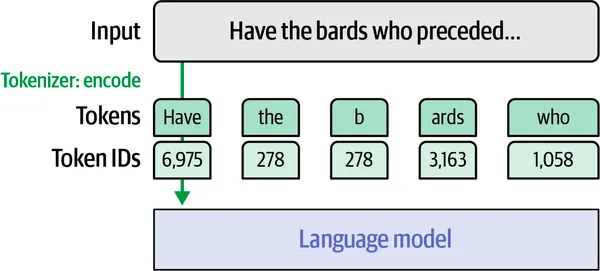

### Paso 2: Embeddings Semánticos (El Significado del Token)

El modelo no trabaja con IDs enteros. Cada ID se usa para buscar un vector en la **matriz de embeddings**, que funciona como un diccionario gigante que asigna a cada token un vector denso con información semántica.

Aquí hay un detalle clave:
**En este punto, los embeddings aún no entienden el contexto.**
El vector de “banco” será el mismo si hablamos de un asiento o de una entidad financiera. Esa desambiguación ocurrirá después, en las capas del Transformer.

A continuación tenéis una representación de un embedding para las palabras [cat, puppy, houses, apple, baby]. En la realidad cada elemento del vector de embeddings (por ejemplo [animal, newborn, human, ...]) no representa un concepto tan claro, y son bastante menos interpretables que el de este ejemplo.



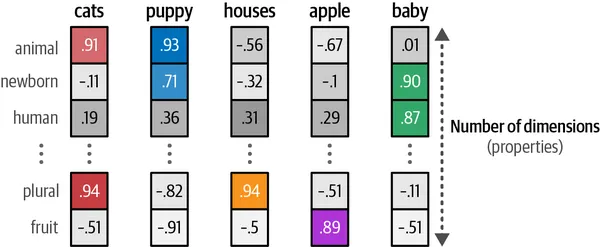

### Paso 3: Codificación Posicional

Los embeddings por sí solos no contienen información sobre el orden de la frase. Sin una pista de posición, el modelo vería una bolsa de vectores sin secuencia.

Para evitarlo, se añade un segundo vector llamado **codificación posicional (PE)**, que indica la posición exacta de cada token. Este vector tiene la misma dimensión que el embedding, y ambos se **suman elemento a elemento**:

> **Vector final = Embedding + Positional Encoding**

Así obtenemos una representación que combina **qué es** el token y **dónde está**. Esta secuencia de vectores final (la matriz (X)) es lo que realmente entra a la primera capa del Transformer.





## El Proceso de Inferencia: De Logits a Resultados
Una vez entrenado el modelo, llega el momento de usarlo. Aunque los detalles cambian según la arquitectura y la tarea, la inferencia puede resumirse en dos grandes pasos.

### 1. Pasar la Secuencia por las Capas del Transformer

La matriz (X) viaja a través de varias capas Transformer, donde ocurre la “magia” del contexto. Según el tipo de capa y su nivel dentro del modelo:

* **Capas inferiores:** se enfocan en relaciones locales: qué tokens están cerca, pequeños patrones, detalles sencillos.
* **Capas superiores:** capturan dependencias más largas y afinan la representación para la tarea final.
* **Encoders:** transforman el embedding para enriquecerlo semánticamente.
* **Decoders:** hacen lo anterior, pero con especial foco en predecir el siguiente token.


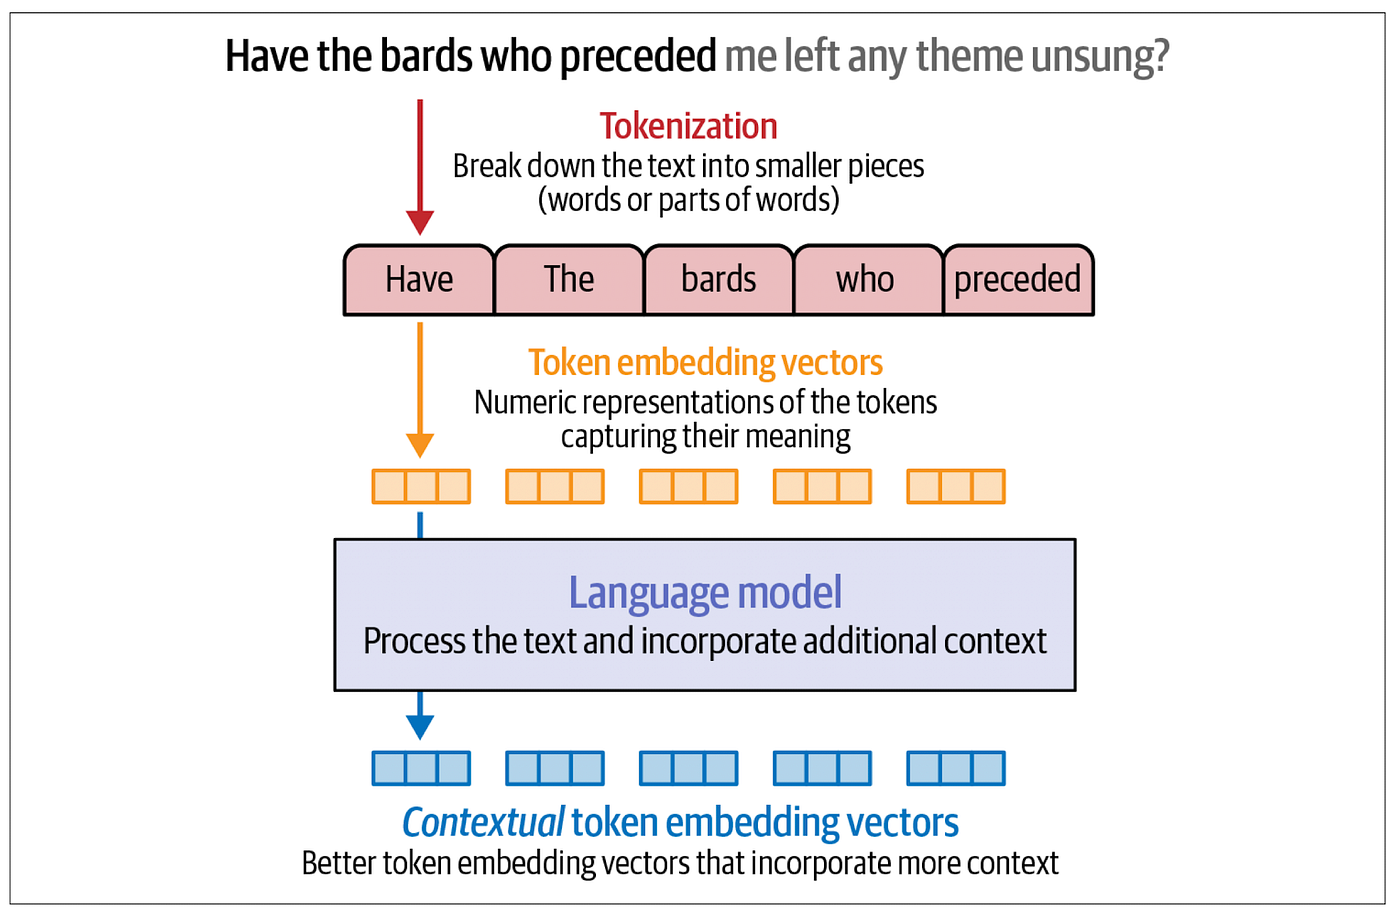


### 2. De Representaciones a Predicciones (Los Logits)

Tras atravesar las capas, la representación final se pasa a una **capa lineal**. El resultado son los **logits**, valores sin normalizar que indican cómo de probable considera el modelo cada clase o token posible.

Luego se aplica una función **softmax** para convertir esos logits en una distribución de probabilidad.

Dependiendo de la tarea:

* En **clasificación**, los logits representan las clases posibles.
* En **generación de texto**, representan los tokens candidatos.
* Si solo queremos **representaciones vectoriales**, este paso final puede omitirse.



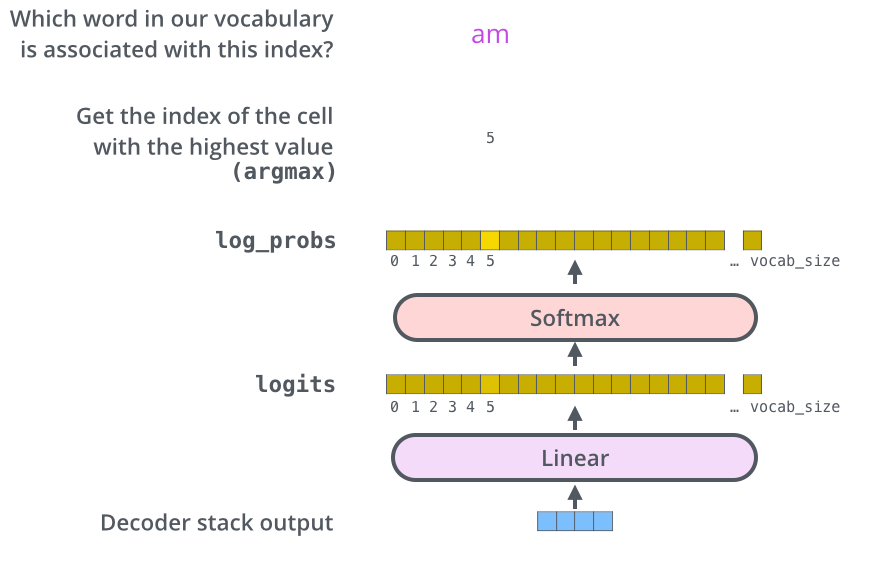


------------
## Los Tres Arquetipos de Transformers

Aunque comúnmente se habla de "El Transformer", la arquitectura original es en realidad un conjunto de bloques de construcción: bloques de Codificador (Encoder) y bloques de Decodificador (Decoder). La forma en que estos bloques se ensamblan, o se usan por separado, da lugar a tres arquetipos principales de modelos que dominan el panorama del PNL.


| Característica | Encoder-Only (Ej. BERT, RoBERTa) | Decoder-Only (Ej. GPT, LLaMA, Gemma) | Encoder-Decoder (Ej. T5, BART) |
| :--- | :--- | :--- | :--- |
| **Bloques Utilizados** | Solo Pila de Codificadores | Solo Pila de Decodificadores (Modificada) | Pila de Codificadores + Pila de Decodificadores  |
| **Mecanismo de Atención** | Autoatención Bidireccional | Autoatención Causal (Enmascarada) | Bidireccional (Enc), Causal (Dec), Cruzada (Puente) |
| **Objetivo Principal** | Comprensión del Lenguaje (NLU) | Generación de Lenguaje (NLG)  | Transformación de Secuencia-a-Secuencia (Seq2Seq) |
| **Tarea de Pre-entrenamiento** | Masked Language Modeling (MLM) | Causal Language Modeling (CLM) (Pred. Siguiente Token)  | Objetivos mixtos (p.ej., Denoising, Text-to-Text)  |
| **Casos de Uso Típicos** | Clasificación, NER, Extracción | Chatbots, Escritura Creativa, Finalización de Código | Traducción, Resumen, Preguntas y Respuestas (Generativas) |
| **Formato de Salida** | Un vector de *embedding* por token / Una etiqueta de clase | Una secuencia de tokens generados | Una secuencia de tokens generados *condicionada* a la entrada |

---------------

## Instalación de Dependencias



In [ ]:
!pip install --upgrade bertopic datamapplot

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.5/168.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 24.6 MB/s eta 0:00:00
  Created wheel for Pyqtree: filename=Pyqtree-1.0.0-py3-none-any.whl size=5969 sha256=e1e2cd73572950c06f7fd9ee9f321f8a48d243be053c3ba77a1707274ed14349
  Stored in directory: /root/.cache/pip/wheels/86/02/24/506ac193949f48c8bec599b613d722bd64a83063a190b3bff7
Successfully built Pyqtree
  Attempting uninstall: dask
    Found exist

In [ ]:
import gc
import torch
import copy

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, AutoModelForMaskedLM, pipeline

----------

# *Laboratorio 3D:* Parte Práctica

## Primera Parte

En esta parte trabajaréis con los tokenizadores y aprenderéis mejor cómo funcionan y como impactan sus diferencias a la hora de representar texto.


### **Ejercicios:**






#### 1.  **Ver el proceso de encoding y decoding de un tokenizador:**

*   Toma la frase de ejemplo y el tokenizador del modelo `bert-base-cased`
*   Aplica el método `encode` del tokenizador para obtener los IDs numéricos.
*   Aplica el método `decode` a esos IDs para reconstruir la frase original.
*   Compara la frase original con la decodificada para identificar posibles pérdidas o cambios.


In [ ]:
# Inicialización
sent = "These spaces         are          slowly                                   moving out 🏃."
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
# Tokenización del texto
tokenized_sentence = tokenizer.tokenize(sent) # Obtenemos los tokens
print(tokenized_sentence)

['These', 'spaces', 'are', 'slowly', 'moving', 'out', '[UNK]', '.']


In [ ]:
# Codificación del texto
encoded_sentence = tokenizer.encode(sent) # Obtenemos los ids de los tokens
print(encoded_sentence)

[101, 1636, 6966, 1132, 2494, 2232, 1149, 100, 119, 102]


In [ ]:
# Decodificación del texto
decoded_sentence = tokenizer.decode(encoded_sentence)
print(decoded_sentence)

[CLS] These spaces are slowly moving out [UNK]. [SEP]


*¿Qué diferencias notáis de la versión original a la reconstruida?*

- Elimina espacios.
- Tokens de principio y final ([CLS] y [SEP]) añadios.
- Emoji sustituido por [UNK]

Vamos a probar con un tokenizador un poco más moderno: `microsoft/phi-4`.

Comprobar si con este tokenizador hay diferencias en el proceso de tokenización/encoding/decoding y en que punto podéis observarlas.

In [ ]:
# Inicialización del tokenizado
sent = "These spaces         are          slowly                                   moving out 🏃."
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-4")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

In [ ]:
# Tokenización del texto
tokenized_sentence = tokenizer.tokenize(sent) # Obtenemos los tokens
print(tokenized_sentence)

['These', 'Ġspaces', 'ĠĠĠĠĠĠĠĠ', 'Ġare', 'ĠĠĠĠĠĠĠĠĠ', 'Ġslowly', 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ', 'Ġmoving', 'Ġout', 'ĠðŁ', 'ı', 'ĥ', '.']


In [ ]:
# Codificación del texto
encoded_sencence = tokenizer.encode(sent)
print(encoded_sentence)

[101, 1636, 6966, 1132, 2494, 2232, 1149, 100, 119, 102]


In [ ]:
# Decodificación del texto
decoded_sentence = tokenizer.decode(encoded_sentence)
print(decoded_sentence)

�aredACTarch nodeQuanc���


#### 2.  **Cargar distintos tokenizadores y compararlos:**

Existen varios tokenizadores, cada uno especializado en algún aspecto o entrenados con nuevas técnicas. Algunos tokenizadores dividen las palabras que no conocen en subpalabras, o en carácteres o _incluso en bytes si no conocen ese caracter_.

A continuación probarás varios tokenizadores, mira con cuidado sus diferencias en los ejemplos y haz un análisis de las diferencias y que lado bueno o malo tiene cada uno.
*   Prueba los siguientes tokenizadores:
    *    `bert-base-uncased`
    *    `xlm-roberta-base`
    *    `facebook/galactica-1.3b`

*   Observa las diferencias en cómo cada uno. Ejem:
    *   Cómo procesan emojis (ej. 🤔, ✨).
    *   Cómo separa las palabras en subtokens
    *   ...

In [ ]:
colors_list = [
    '102;194;165', '252;141;98', '141;160;203',
    '231;138;195', '166;216;84', '255;217;47'
]

def show_tokens(sentences, tokenizer_name):
    if isinstance(sentences, str):
        sentences = sentences.split('\n')
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    for sentence in sentences:
      tokens = tokenizer.tokenize(sentence)
      for idx, t in enumerate(tokens):
          print(
              f'\x1b[0;30;48;2;{colors_list[idx % len(colors_list)]}m' +
              t +
              '\x1b[0m',
              end=' '
          )
      print('\n')

    del tokenizer

In [ ]:
sent1 = """
This is a Simple test. Can YOU See The Difference?     WHY      ARE      WE       SHOUTING?
El desarrollador está desarrollando el programa programado por otro programador.
Just finished my coffee ☕ and I’m ready to code 💻✨
日本語 の 文章 を 書いて います。

(550x+35*6)/30=62 → x = 3
"""

In [ ]:
# TODO - Emplear el método "show_tokens" para probar los distintos tokenizadores y ver sus diferencias. (sent1)

show_tokens(sent1, "bert-base-uncased")
show_tokens(sent1, "xlm-roberta-base")
show_tokens(sent1, "microsoft/phi-4")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]



this is a simple test . can you see the difference ? why are we shouting ? 

el des ##ar ##roll ##ador est ##a des ##ar ##roll ##ando el program ##a program ##ado por ot ##ro program ##ador . 

just finished my coffee [UNK] and i ’ m ready to code [UNK] 

日 本 語 の 文 章 を 書 い ##て い ##ま ##す 。 



( 550 ##x + 35 * 6 ) / 30 = 62 → x = 3 





tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]



▁This ▁is ▁a ▁Simple ▁test . ▁Can ▁YOU ▁See ▁The ▁Di ffer ence ? ▁W HY ▁ ARE ▁WE ▁SH OUT ING ? 

▁El ▁desarrollado r ▁está ▁desarrolla ndo ▁el ▁programa ▁programa do ▁por ▁otro ▁programa dor . 

▁Just ▁finished ▁my ▁coffee ▁ ☕ ▁and ▁I ’ m ▁ready ▁to ▁code ▁ 💻 ✨ 

▁ 日本語 ▁ の ▁ 文章 ▁ を ▁ 書いて ▁ います 。 



▁( 550 x + 35 * 6) /30 = 62 ▁→ ▁x ▁= ▁3 





This Ġis Ġa ĠSimple Ġtest . ĠCan ĠYOU ĠSee ĠThe ĠDifference ? ĠĠĠĠ ĠWHY ĠĠĠĠĠ ĠARE ĠĠĠĠĠ ĠWE ĠĠĠĠĠĠ ĠSH OUT ING ? 

El Ġdesarroll ador ĠestÃ¡ Ġdesarroll ando Ġel Ġprograma Ġprogram ado Ġpor Ġotro Ġprogram ador . 

Just Ġfinished Ġmy Ġcoffee Ġâĺ ķ Ġand ĠI âĢĻm Ġready Ġto Ġcode ĠðŁĴ » âľ ¨ 

æĹ¥ æľ¬ èª ŀ Ġãģ® Ġæĸĩ ç«ł ĠãĤĴ ĠæĽ ¸ ãģĦ ãģ¦ Ġ ãģĦãģ¾ãģĻ ãĢĤ 



( 550 x + 35 * 6 )/ 30 = 62 ĠâĨĴ Ġx Ġ= Ġ 3 





_Análisis:_

bert-base-uncased:
- Mayúsculas/Minúsculas: No usa mayúsculas, lo pasa todo a minúscula.
- Emojis: No los reconoce y los transforma en el token [UNK], perdiendo información.
- Subtokens: Usa WordPiece, divide palabras desconocidas en partes.
- Ecuación: Divide la ecuación caracter por caracter.
- Alfabetos diferentes: Los reconoce y los puede recrear, pero separa cada caracter en un token diferente.

xlm-roberta-base:
- Mayúsculas/Minúsculas: Mantiene tanto mayúsculas como minúsculas.
- Emojis: Los reconoce y los puede recrear.
- Subtokens: Usa SentencePiece, descompone en subpalabras, siendo mejor para idiomas con aglutinación (Euskera, por ejemplo).
- Ecuación: Similar al bert, pero mejor normalización de números.
- Alfabetos diferentes: Los reconoce y los puede recrear, creando subtokens mejores.

microsoft/phi-4:
- Mayúsculas/Minúsculas: Mantiene tanto mayúsculas como minúsculas.
- Emojis: No los puede recrear, pero usa tokens distintos para cada uno.
- Subtokens: Usa tiktoken/BPE moderno. Crea menos tokens y mejora la compresión.
- Ecuación: Agrupa mejor los números y operadores.
- Alfabetos diferentes: En su lugar pone otras letras.

Como ultimo ejercicio, calcula el ratio de conversión de palabras (separadas por espacios) a tokenes de cada modelo usando `sent1`:

In [ ]:
# Tokenizador modelo 1
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
tokenized_sent = tokenizer.tokenize(sent)
num_tokens = len(tokenized_sent)
num_sent_words = len(sent1.split()) # Definimos una palabra como el elemento separado por espacios

print("num_sent_words:", num_sent_words)
print("len(tokenized_sent):", num_tokens)
ratio_tokens_words = num_tokens / num_sent_words
print("ratio_tokens_words:", ratio_tokens_words)

num_sent_words: 46
len(tokenized_sent): 8
ratio_tokens_words: 0.17391304347826086


In [ ]:
# Tokenizador modelo 2
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
tokenized_sent = tokenizer.tokenize(sent)
num_tokens = len(tokenized_sent)
num_sent_words = len(sent1.split()) # Definimos una palabra como el elemento separado por espacios

print("num_sent_words:", num_sent_words)
print("len(tokenized_sent):", num_tokens)
ratio_tokens_words = num_tokens / num_sent_words
print("ratio_tokens_words:", ratio_tokens_words)

num_sent_words: 46
len(tokenized_sent): 10
ratio_tokens_words: 0.21739130434782608


In [ ]:
# Tokenizador modelo 3
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-4")
tokenized_sent = tokenizer.tokenize(sent)
num_tokens = len(tokenized_sent)
num_sent_words = len(sent1.split()) # Definimos una palabra como el elemento separado por espacios

print("num_sent_words:", num_sent_words)
print("len(tokenized_sent):", num_tokens)
ratio_tokens_words = num_tokens / num_sent_words
print("ratio_tokens_words:", ratio_tokens_words)

num_sent_words: 46
len(tokenized_sent): 13
ratio_tokens_words: 0.2826086956521739


**Ratios conversion modelos**:
* Modelo1: 0.17391304347826086
* Modelo2: 0.21739130434782608
* Modelo3: 0.2826086956521739

**Preguntas:**
* Si quisieramos tokenizar un corpus de 5 billones (americanos) de palabras, de cuantos tokenes estaríamos hablando por cada modelo?
    - Modelo1: 5×10^12 × 0.174 = 0.87×10^12 tokens
    - Modelo2: 5×10^12 × 0.217 = 1.085×10^12 tokens
    - Modelo3: 5×10^12 × 0.283 = 1.415×10^12 tokens

* ¿Cuál es el modelo más eficiente en codificación?
    - Modelo1 (Bert), ya que es el que menor ratio de tokens/palabra, es decir, el que mejor comprime el texto.

* ¿Crees que el ratio cambiaría si fuera otro idioma, por ejemplo un texto en japonés?
    - Sí. En el anterior ejercicio ya hemos comprobado que los modelos no trabajan igual de bien con el alfabeto latino que con otros como el japonés.

----------------------------
## Segunda Parte

**Objetivo:** Trabajar distintos errores de carga, y aprender cuáles son los hiperparámetros de entrenamiento.

En esta sección lidiaréis con posibles errores que pueden suceder cuando se trabaja transteando con modelos propios, entrenados de diversas formas, o cuando se quieren reutilizar y expandir estos modelos.

También con ciertos inconvenientes que pueden suceder al emplear modelos generativos.

### **Ejercicios:**

#### 1.  **Intentar cargar un modelo con una configuración que no es la original:**

*   Modifica manualmente la configuración del modelo preentrenado. Prueba con los siguientes campos de la configuración, cambiándolos a valores que no sean los originales (no None):
    * _num\_attention\_heads_ (probar con un valor superior)
    * _hidden\_size_ (un valor distinto)
    * _attention_probs_dropout_prob_ (un valor distinto)
*   Intenta cargar un modelo utilizando esta configuración modificada.
*   Observa los errores que se producen y comprende por qué son importantes las configuraciones correctas.

**IMPORTANTE**

Estamos cargando modelos ya entrenados, que ya tienen una arquitectura y unos pesos definidos. Hay algunos campos de la configuración que cambian la arquitectura del modelo y otros que no. Detectar cuáles son y razonar porqué no se pueden cambiar.

__Extra:__ En el caso de `num_attention_heads`, si se pone un valor inferior no da error. ¿Por qué es? ¿Qué son las attention heads?

In [ ]:
# Comprobar la configuración
model_name = 'bert-base-uncased'
config = AutoConfig.from_pretrained(model_name)
print(config)

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [ ]:
# Cambio de la configuración de num_attention_heads
model_name = 'bert-base-uncased'
config = AutoConfig.from_pretrained(
    model_name,
    num_attention_heads=4
)
model = AutoModelForMaskedLM.from_pretrained(model_name, config=config)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
# Cambio de la configuración de hidden_size
model_name = 'bert-base-uncased'
config = AutoConfig.from_pretrained(
    model_name,
    hidden_size=768
)
model = AutoModelForMaskedLM.from_pretrained(model_name, config=config)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
# Cambio de la configuración de attention_probs_dropout_prob
model_name = 'bert-base-uncased'
config = AutoConfig.from_pretrained(
    model_name,
    attention_probs_dropout_prob=0.4
)
model = AutoModelForMaskedLM.from_pretrained(model_name, config=config)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


* ¿Por qué hay parámetros de la configuración que puedes cambiar y otros que no?
    - Al ser un modelo preentrenado, no podemos cambias los parámetros que cambien la forma de los pesos. Los que no afecten a los pesos, en cambio, sí.
* ¿En que caso crees que no darían error?
    - num_attention_heads: Cuando el número sea igual o menor al original; puede dejar attention heads sin usar, pero no usar unos que no existen.
    - hidden_size: Como dice el mensaje de error al poner un número erróneo, tiene que ser un múltiplo de num_hidden_layers
    - attention_probs_dropout_prob: Al ser una probabilidad, no dará error mientras sea un valor entre 0 y 1.

#### 2.  **Cargar un tokenizador distinto al del modelo, y ver qué pasa:**

*   Carga un modelo y un tokenizador que no le corresponde.
    *   Modelo a emplear: `openai-community/gpt2`
    *   Tokenizador a emplear: `bigscience/bloom-560m`
*   Intenta tokenizar las siguientes dos frases con el tokenizador incorrecto y luego pasa los IDs al modelo.
*   Analiza los resultados (errores, salidas sin sentido (si las hay), etc.) y por qué ha dado error o no, y la causa de otros resultados que hayas obtenido. Si hay diferente resultado entre las frases indica por qué puede ser.


In [ ]:
# Cargar el tokenizador y modelo
tokenizer_inadecuado = AutoTokenizer.from_pretrained("bigscience/bloom-560m")
model = AutoModelForCausalLM.from_pretrained('openai-community/gpt2')

pipeline_text_generation = pipeline("text-generation", model=model, tokenizer=tokenizer_inadecuado)

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
sent = "Hello, I am a language model, and I can" # TODO. Podéis probar otras frases
generated_text = pipeline_text_generation(sent, max_length=50, num_return_sequences=1)
print(generated_text[0]['generated_text'])

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


IndexError: index out of range in self

Para entender un poco mejor porqué no funciona, prueba a decodificar el texto codificado (con el tokenizador de bloom) para entender mejor qué recibe el modelo.

In [ ]:
tokenizador_adecuado = AutoTokenizer.from_pretrained("openai-community/gpt2")

# Obtener el texto codificado
encoded_sentence = tokenizer_inadecuado.encode(sent)
print(encoded_sentence)

# Decodificar el texto
decoded_sentence = tokenizador_adecuado.decode(encoded_sentence) # TODO
print(decoded_sentence)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[59414, 15, 473, 912, 267, 16340, 5550, 15, 530, 473, 1400]
0 sats oinv DE0 one sa No


* ¿Qué conclusiones sacas?
    - Que no se puede usar un tokenizador distinto al del modelo, porque no se va a funcionar.

* Aunque los modelos no entiendan de palabras y letras, ¿por qué es importante usar el tokenizador adecuado?
    - Porque cada modelo tiene su propio vocabulario, y es imposible que un modelo entienda el de otro.

In [ ]:
# Hacemos limpieza:
del pipeline_text_generation
del model
del tokenizer_inadecuado
del tokenizador_adecuado

In [ ]:
# Flush memory
gc.collect()
torch.cuda.empty_cache()

#### 3.  **Cargar modelos, y darle una frase demasiado larga:**
*   Identifica el `max_position_embeddings` o `n_ctx` o `n_positions` de un modelo (la longitud máxima de secuencia que puede manejar).


In [ ]:
# Carga la configuración del modelo para localizar la longitud máxima que acepta
model_name = 'openai-community/gpt2'
config = AutoConfig.from_pretrained(model_name)
print(config)

GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.57.2",
  "use_cache": true,
  "vocab_size": 50257
}



* **Longitud Máxima**: 1024 tokens

Ahora vamos a cargar el tokenizador y el modelo configurando una longitud máxima inferior (la real del modelo es demasiado larga para este laboratorio)




In [ ]:
def load_custom_length_model(model_name, max_model_length):
    _model = AutoModelForCausalLM.from_pretrained(model_name)
    _model.transformer.wpe.weight.data = _model.transformer.wpe.weight.data[:max_model_length, :].clone()
    _model.transformer.wpe.num_embeddings = max_model_length
    return _model

def load_custom_length_pipeline(model_name, max_model_length,tokenizer):
    model = load_custom_length_model(model_name, max_model_length)
    pipeline_text_generation = pipeline("text-generation", model=model, tokenizer=tokenizer)
    return lambda _sent, max_new_tokens, return_tensors=None, truncation=True: pipeline_text_generation(
        _sent,
        max_new_tokens=max_new_tokens,
        num_return_sequences=1,
        truncation=truncation,
        handle_long_generation="hole" ,
        return_tensors=return_tensors,
        return_full_text = (return_tensors is None) or None,
    )

In [ ]:
max_model_length = 75
tokenizer = tokenizer = AutoTokenizer.from_pretrained(model_name, model_max_length=max_model_length)
pipeline_text_generation = load_custom_length_pipeline(model_name, max_model_length, tokenizer)

sent = 'Famous Citations:\nYou cannot acquire experience by making experiments. You cannot create experience. You must undergo it. - Albert Camus'

Device set to use cpu


Vamos a probar a generar permitiéndole distintos tokens máximos generados.

* Observa la diferencia de los fragmentos generados.

In [ ]:
# Generando 45 nuevos tokens
pipeline_text_generation(sent, max_new_tokens=45)[0]['generated_text']

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


"Famous Citations:\nYou cannot acquire experience by making experiments. You cannot create experience. You must undergo it. - Albert Camus\nI've got my own way. - Michael Jackson\nThe point of the game is to win. To succeed, you must achieve a certain goal.\nI'm not saying that you're able to do it, but"

In [ ]:
# Generando 60 nuevos tokens
pipeline_text_generation(sent, max_new_tokens=60)[0]['generated_text']

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'Famous Citations:\nYou cannot acquire experience by making experiments. You cannot create experience. You must undergo it. - Albert Camus'

In [ ]:
# Generando 70 nuevos tokens
pipeline_text_generation(sent, max_new_tokens=70)[0]['generated_text']

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


"Famous Citations:\nYou cannot acquire experience by making experiments. You cannot create experience. You must undergo it. - Albert Camus\n\nYou're gonna know where you're going, this is for you. - Michael Jackson\n\nI'm going to go to the river, it's gonna be a very nice day. - The Beatles\n\nWhat's your name? - The Pope\n\nI'm going to tell you something. - The Beatles\n\nYou want to"

In [ ]:
# Generando 74 nuevos tokens
pipeline_text_generation(sent, max_new_tokens=74)[0]['generated_text']

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'Famous Citations:\nYou cannot acquire experience by making experiments. You cannot create experience. You must undergo it. - Albert Camus "The man who was able to make all the difference in the world. I never heard anyone ask me why I did it. I didn\'t want to be one of those people that is ashamed to say \'I did it\'."\n\n"I don\'t think I would ever say that to someone who had really studied the world, or to anyone who had done it'

* ¿Qué diferencias has notado en el contenido del texto y su coherencia con respecto al input?
    - A medida que los tokens aumentan, pierde la coherencia y recurre a repeticiones.
* ¿Hay algo que te descuadre?
    - Que con 60 tokens devuelva el texto original, sin cambios.

Para continuar con el ejercicio, ahora tomaremos directamente los ids de los tokens que ha visto el modelo y analizaremos el contenido.

In [ ]:
# Generando 45 nuevos tokens
generated_tokens = pipeline_text_generation(sent, max_new_tokens=45, return_tensors=True)[0]['generated_token_ids']
print(len(generated_tokens))
decoded_tokens = tokenizer.decode(generated_tokens)
print(decoded_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


73
Famous Citations:
You cannot acquire experience by making experiments. You cannot create experience. You must undergo it. - Albert Camus (1852-1915)
In this passage, "experimentation" is the "concept or practice of making something useful by the task of doing something". I think we should also think of "making something useful


In [ ]:
# Generando 60 nuevos tokens
generated_tokens = pipeline_text_generation(sent, max_new_tokens=60, return_tensors=True)[0]['generated_token_ids']
print(len(generated_tokens))
decoded_tokens = tokenizer.decode(generated_tokens)
print(decoded_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


75
. You cannot create experience. You must undergo it. - Albert Camus

A better example of this is the rise of the "free market." The market is a system of laws and regulations that favor certain groups or individuals over others. The free market, like all rules, is a product of many factors, from the power of the market to the influence of the


In [ ]:
# Generando 70 nuevos tokens
generated_tokens = pipeline_text_generation(sent, max_new_tokens=70, return_tensors=True)[0]['generated_token_ids']
print(len(generated_tokens))
decoded_tokens = tokenizer.decode(generated_tokens)
print(decoded_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


75
. - Albert Camus (R)

- Joe Allen (R)

- Brandon Rush (R)

- Jordan Reed (R)

- Tony Wroten (R)

- Joe Johnson (R)

- Ryan Kerrigan (R)

- Kendall Langford (R)

- DeAngelo Williams (


In [ ]:
# Generando 74 nuevos tokens
generated_tokens = pipeline_text_generation(sent, max_new_tokens=74, return_tensors=True)[0]['generated_token_ids']
print(len(generated_tokens))
decoded_tokens = tokenizer.decode(generated_tokens)
print(decoded_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


75
us.

"He asked me if I was going to go out of my way to get involved in politics. In a way, he said I was," said Sanders, who has been fighting in the Democratic primary for months. "And I gave him what I had told him: 'If you want to be a political person, go for it.'"

But


* ¿Qué puedes observar al ver los tokenes que el modelo ha visto y generado?
    - Que siempre llega a 75 como el máximo, ya que es así como está configurado.
* ¿Cómo lo relacionas con la primera parte del ejercicio?
    - Que se pueden usar menos de los que están creados, pero no más.
* ¿Puedes explicar qué ha sucedido?
    - El modelo está configurado con un límite de 75 a la hora de ser preentrenado. Al intentar superarlo, no es capaz, así que se trunca.

Puedes emplear esta imagen de apoyo:

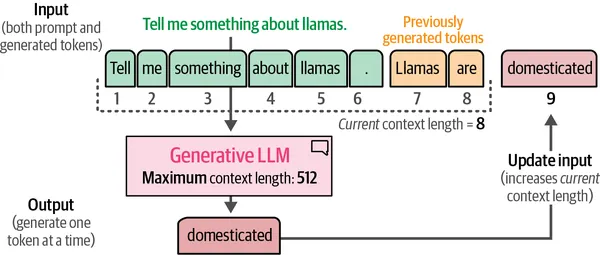

In [ ]:
# Hacemos limpieza:
del pipeline_text_generation
del tokenizer

In [ ]:
# Flush memory
gc.collect()
torch.cuda.empty_cache()

---------------------------------
## Tercera Parte

Aquí emplearemos los modelos de lenguaje para llevar a cabo tareas de clustering (embeddings) y de topic modeling.

En este caso es importante destacar que los embeddings que obtendremos serán mucho más significativos semánticamente pues se tratan de embeddings contextuales.





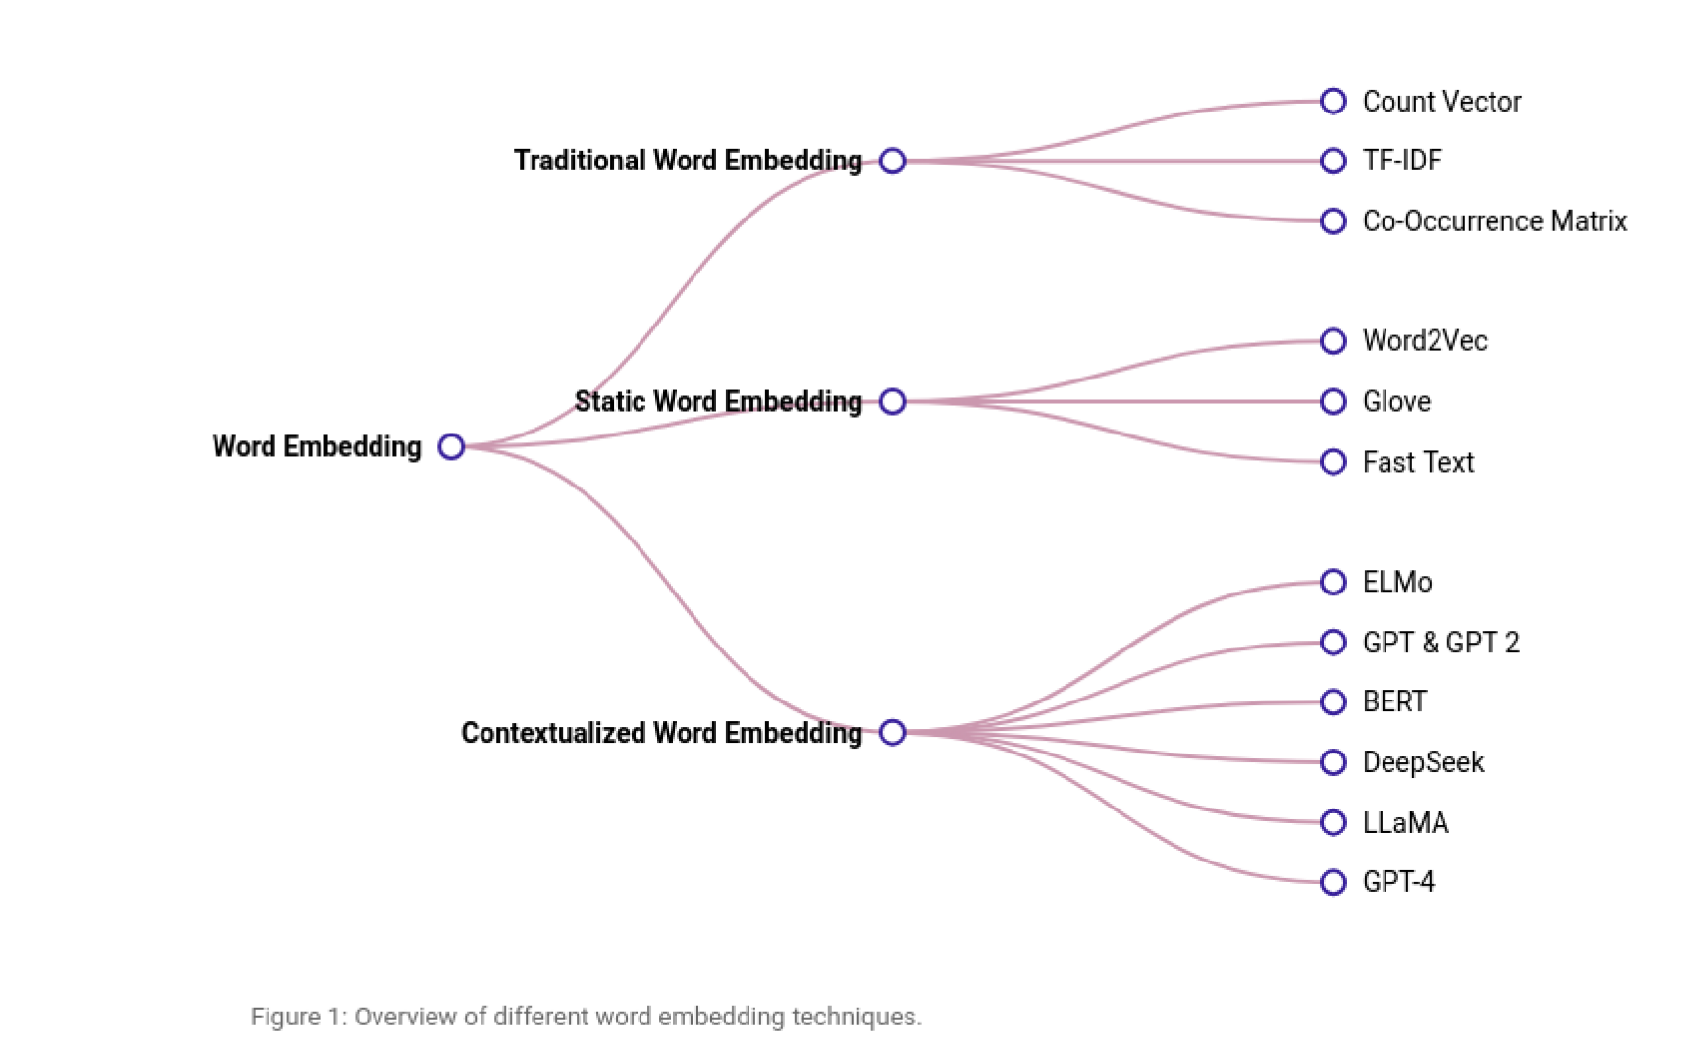


### **Ejercicios:**

#### 1.  **Obtener los embeddings empleando encoders:**
*   Carga el conjunto de documentos y obten los campos que nos interesan
    * Dataset: `maartengr/arxiv_nlp`, split: `train`
    * Campos: `Titles` y `Abstracts`

*   Carga un modelo Encoder para obtener las representaciones vectoriales.
    * Emplearemos la librería **SentenceTransformer** especializada en esta tarea (https://sbert.net/).
    * Modelo: `thenlper/gte-small` (podéis probar otros modelos, etse es un **General Text Embeddings (GTE)**)
*   Procesa los abstracts a través del Encoder para obtener sus embeddings contextualizados (representaciones vectoriales).


In [ ]:
from datasets import load_dataset

# Cargamos el dataset de Huggingface
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Obtenemos los campos que nos interesan
titles = dataset["Titles"]
abstracts = dataset["Abstracts"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/53.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
from sentence_transformers import SentenceTransformer

# Cargamos el modelo de Embeddings y obtenemos los embeddings
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [ ]:
# Checkeamos la dimensión de los embeddings
embeddings.shape

(44949, 384)

* ¿Qué representa cada valor de la tupla?
    - 44949: Número de documentos (abstracts) procesados.
    - 384: Dimensión de cada embedding (número de características del vector).

#### 2.  **Hacer clustering de los embeddings (y Topic Modeling):**

*   Reduce la dimensión de los embeddings obtenidos para que los calculos sean más ligeros.
    * Usaremos UMAP para ello (https://umap-learn.readthedocs.io/en/latest/)
*   Aplica algoritmos de clustering como K-Means, DBSCAN o HDBSCAN para agrupar los embeddings.
    * En este caso se empleará HDBSCAN (https://hdbscan.readthedocs.io/en/latest/index.html)
*   Interpreta algunos clusters para identificar posibles temas o categorías latentes en los datos.




In [ ]:
from umap import UMAP

# Reducimos el inpit a 5 dimensiones (puede ser otro valor, si queréis hacer pruebas)
umap_model = UMAP(
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
from hdbscan import HDBSCAN

# Generamos el modelo de clustering y obetnemos los clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric='euclidean',
    cluster_selection_method='eom'
).fit(reduced_embeddings)

clusters = hdbscan_model.labels_

# ¿Cuántos clusters hemos generado?
len(set(clusters))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


155

In [ ]:
import numpy as np

# Printea los primeros documentos de los primeros clusteres e intenta ver cuál es el tópico de ese cluster
for cluster in range(4):
    print('-'*20)
    print(f'Cluster {cluster}\n')
    for index in np.where(clusters==cluster)[0][:3]:
        print(abstracts[int(index)][:300] + "... \n")
    print('\n\n')

--------------------
Cluster 0

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 




--------------------
Cluster 1

  A computer mo

¿Ves alguna temática en los documentos?

* Cluster 0: Documentos sobre traducción automática a lenguaje de signos, síntesis de gestos y animación en ASL.
* Cluster 1: Papers sobre detección automática de humor, análisis de chistes y captions cómicas.
* Cluster 2: Artículos enfocados en detección de sarcasmo en textos y análisis de sentimientos con sarcasmo.
* Cluster 3: Documentos sobre análisis de contratos, lenguaje estructurado y representación de conocimiento formal.

#### 3.  **Obtención de Keywords y Descripción (topic) del cluster:**
En esta sección obtendremos automáticamente tanto las **keywords** como el **tema (topic)** de cada cluster de forma automática empleando modelos de lenguaje.

Para ello emplearemos la librería **BERTopic** que se especializa en esta tarea.
* https://maartengr.github.io/BERTopic/index.html

Los pasos serán los siguientes:
* Definir el modelo de topicos usando la clase ``BERTopic`. A esta clase le pasaremos:
    * Los embeddings originales (`embedding_model`).
    * Los embeddings reducidos (`umap_model`).
    * El modelo de clustering y los clusteres (`hdbscan_model`)
* Obtener los topicos o keywords.
    * El modelo internamente usará c-TF-IDF para obtener las keywords.


En resumen este sería el pipeline en general (en cada paso salen varias opciones):

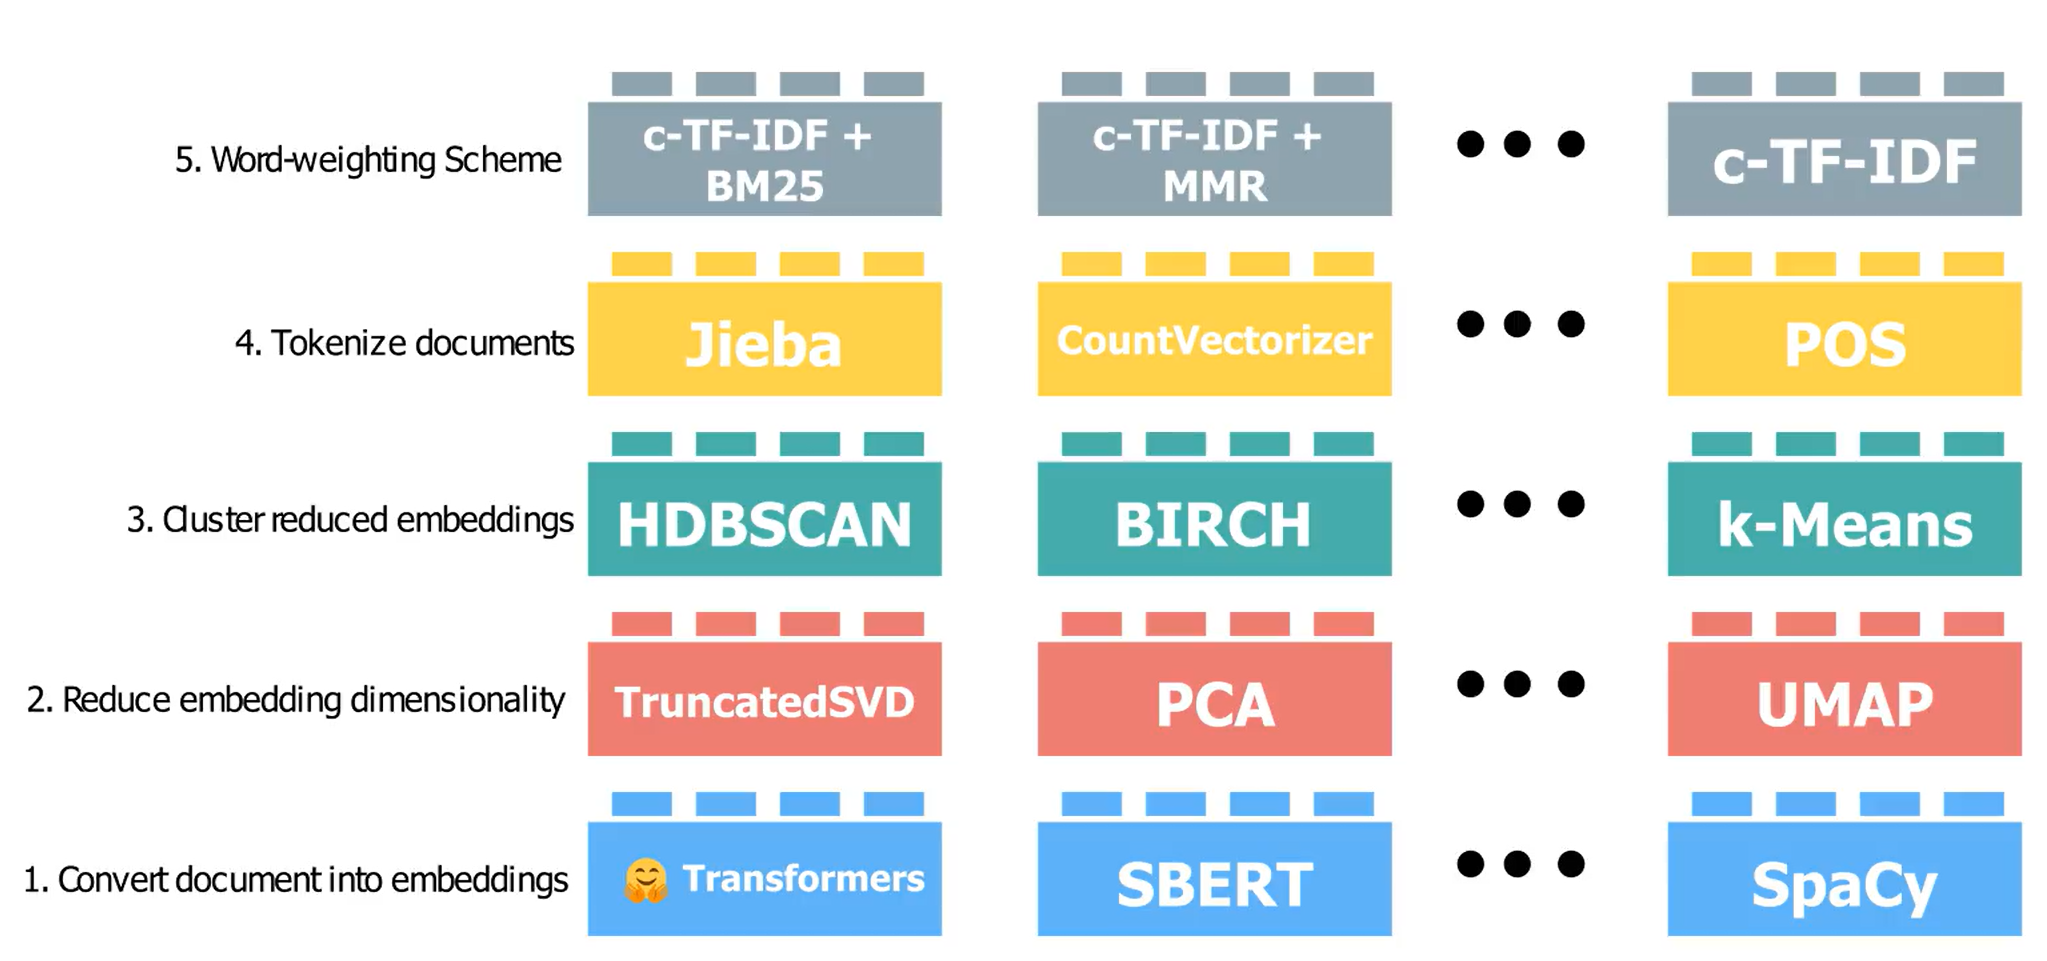

El pipeline exacto que llevaremos a cabo en este laboratorio, y del que ya habéis cargado 3 bloques) es el siguiente:

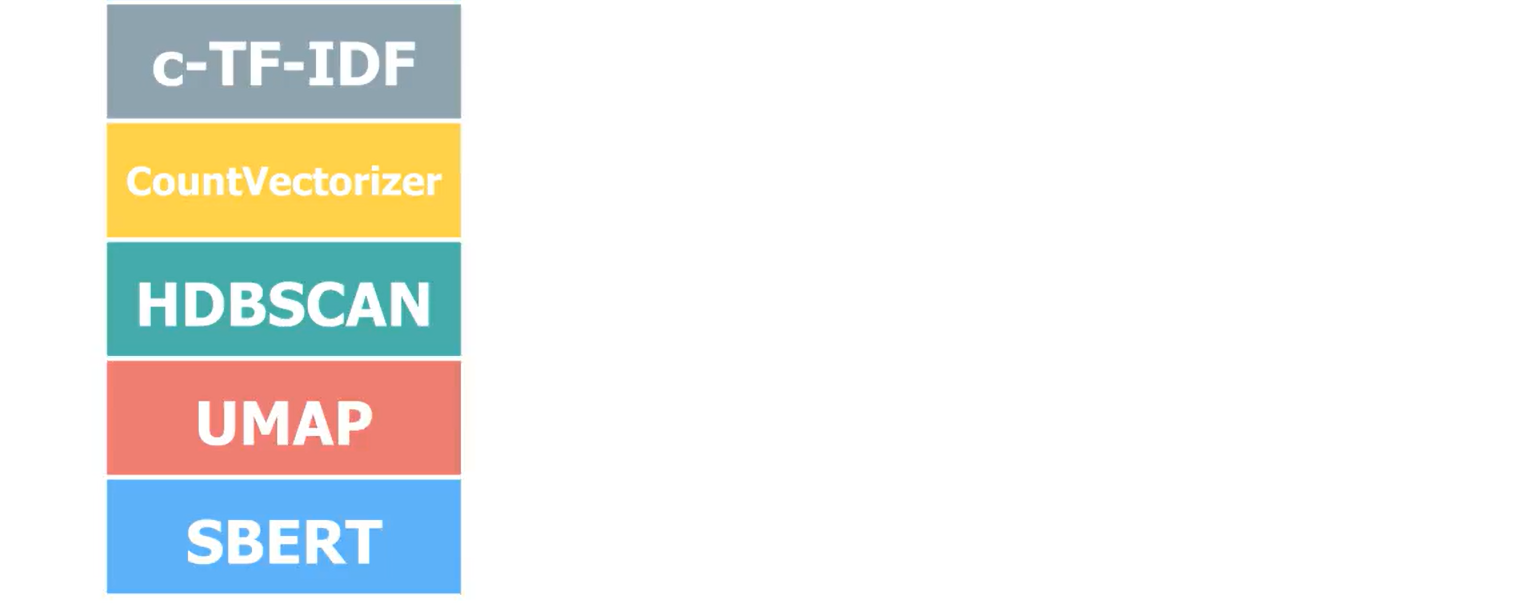

In [ ]:
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2025-11-29 21:14:34,659 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-29 21:15:33,946 - BERTopic - Dimensionality - Completed ✓
2025-11-29 21:15:33,948 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-29 21:15:40,430 - BERTopic - Cluster - Completed ✓
2025-11-29 21:15:40,451 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-29 21:15:47,250 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14210,-1_of_the_and_to,"[of, the, and, to, in, we, language, for, that...",[ GPT-$3$ has attracted lots of attention due...
1,0,2316,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, spea...",[ The speech chain mechanism integrates autom...
2,1,2183,1_question_qa_questions_answer,"[question, qa, questions, answer, answering, a...",[ Text-based Question Generation (QG) aims at...
3,2,941,2_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...","[ Recently, the development of neural machine..."
4,3,880,3_summarization_summaries_summary_abstractive,"[summarization, summaries, summary, abstractiv...",[ Sentence summarization shortens given texts...
...,...,...,...,...,...
150,149,54,149_sentence_embeddings_sts_embedding,"[sentence, embeddings, sts, embedding, similar...",[ Sentence representation at the semantic lev...
151,150,54,150_gans_gan_adversarial_generation,"[gans, gan, adversarial, generation, generativ...",[ Text generation is of particular interest i...
152,151,54,151_coherence_discourse_paragraph_text,"[coherence, discourse, paragraph, text, cohesi...",[ While there has been significant progress t...
153,152,53,152_chatgpt_its_openai_tasks,"[chatgpt, its, openai, tasks, has, ai, capabil...","[ Over the last few years, large language mod..."


* Analiza y explica brevemente el pipeline que ha dado el procesi `fit` del modelo de topicos `BERTopic`.
    - Tiene 3 pasos principales:
        1. Dimensionality: UMAP comprime los embeddings originales de 384 dimensiones a solo 5 para hacer que los cálculos sean más eficientes, manteniendo la semántica.
        2. Cluster: HDBSCAN agrupa los documentos reducidos en 155 clusters distintos, según su densidad.
        3. Representation: Extrae keywords de cada cluster usando c-TF-IDF. Esto identifica las palabras más representativas y únicas de cada tópico.

* Enlaza ese proceso con el output obtenido en `topic_model.get_topic_info()`
    - Cada fila es un tópico con su ID, count de documentos, keywords representativos y ejemplos de documentos.

* ¿La representación (keywords) obtenida de los clusteres se parece a lo que has observado al analizar manualmente los clusteres?
    - Sí, los keywords reflejan bien los temas reales.

A continuación probaremos una forma alternativa de limpiar y pulir las Keywords usando un modelo de representación. Hay diversas alternativas, en este laboratorio probaremos 2: KeyBERT y un modelo generativo.

Comenzamos con KeyBERT:
 * https://maartengr.github.io/BERTopic/getting_started/representation/representation.html#keybertinspired

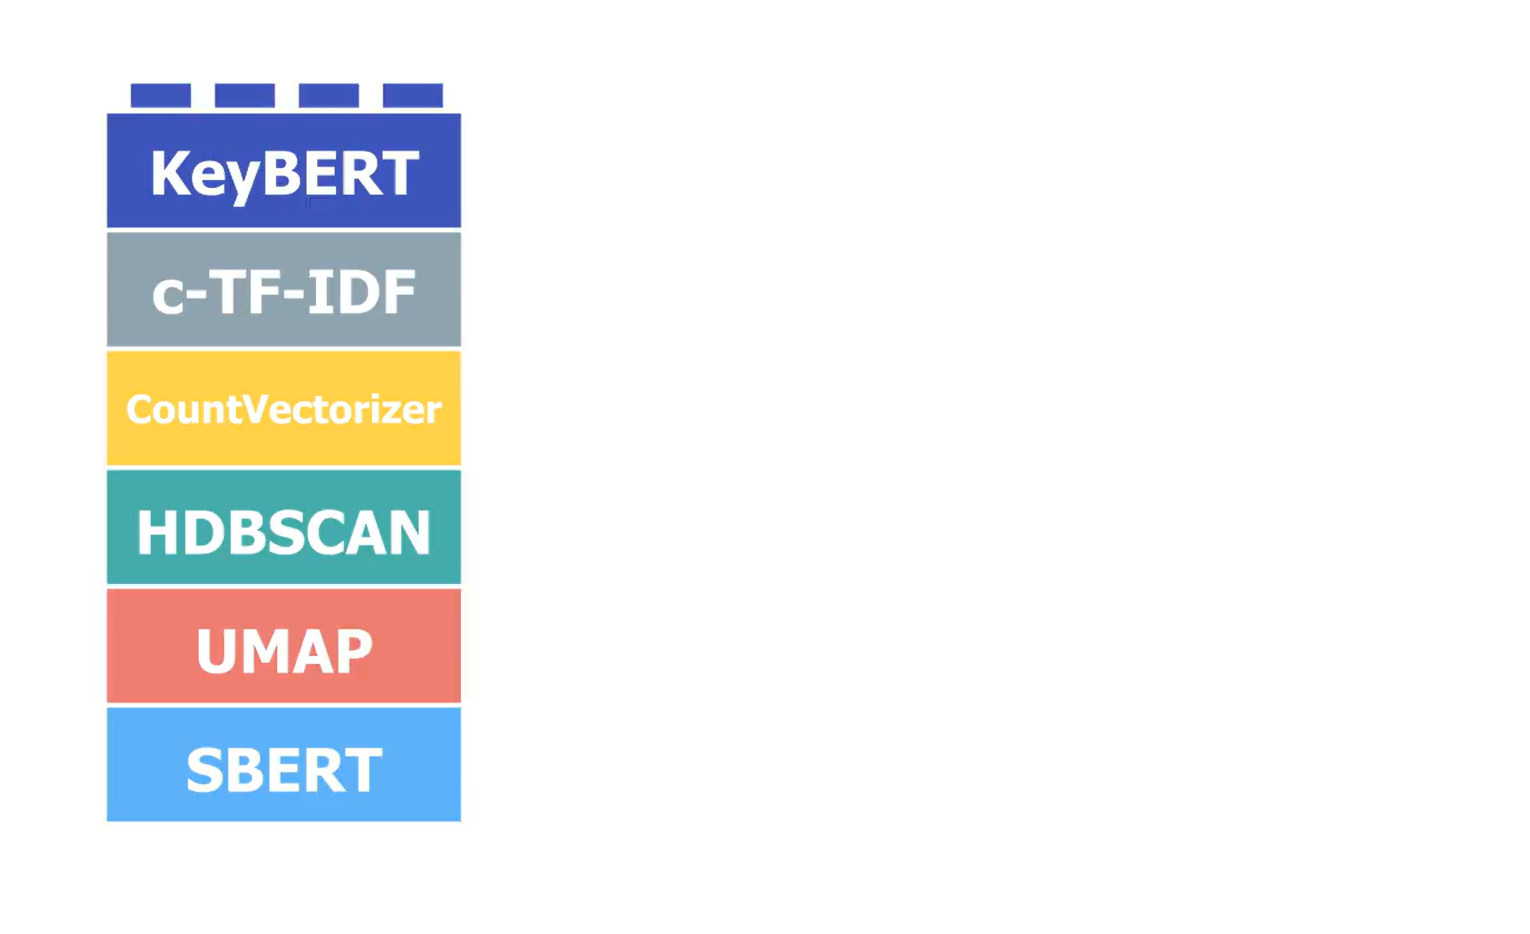

In [ ]:
# Guardamos las keywords originales usando c-TF-IDF para poderlas comparar
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [ ]:
# Método para comparar los resultados
import pandas as pd
def topic_differences(model, original_topics, nr_topics=8):
    """Show the differences in topic representations between two models """
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

In [ ]:
from bertopic.representation import KeyBERTInspired

# Actualizamos las representaciones empleando KeyBERT
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# Comparamos ambas versiones de los keywords
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,phonetic | encoder | transcription | speech | ...
1,1,question | qa | questions | answer | answering,answering | comprehension | questions | questi...
2,2,translation | nmt | machine | bleu | neural,translation | translate | translations | trans...
3,3,summarization | summaries | summary | abstract...,summarization | summarizers | summaries | summ...
4,4,hate | offensive | speech | detection | toxic,hate | hateful | language | offensive | languages
5,5,gender | bias | biases | debiasing | fairness,gendered | gender | bias | biases | biased
6,6,relation | extraction | re | relations | entity,relations | relation | relational | extracting...
7,7,ner | entity | named | recognition | entities,entity | entities | name | named | labeled


* ¿Qué diferencias aprecias?
    - KeyBERT produce keywords más variados y con formas verbales.
* ¿Qué Keywords te parece que representan mejor el cluster?
    - KeyBERT, ya que busca palabras relacionadas con los documentos al completo, no palabras que solo aparezcan como c-TF-IDF.
* ¿Alguna otra observación?

A continuación emplearemos un modelo generativo para llevar a cabo la obtención de la temática del cluster.

En este caso se podría emplear:
* Un modelo encoder-decoder (seq2seq) como por ejemplo `google/flan-t5-small`
* Un modelo decoder como GPT2 (`openai-community/gpt2`) o OpenELM (`apple/OpenELM-270M`)

* Documentación: https://maartengr.github.io/BERTopic/getting_started/representation/llm.html

In [ ]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# Update our topic representations using Flan-T5
generator = pipeline('text2text-generation', model='google/flan-t5-small')

# generator = pipeline("text-generation", model='openai-community/gpt2')
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
)

topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
100%|██████████| 155/155 [01:35<00:00,  1.62it/s]


,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,Speech-to-speech synthesis | | | |
1,1,question | qa | questions | answer | answering,Question answering systems | | | |
2,2,translation | nmt | machine | bleu | neural,Science/Tech | | | |
3,3,summarization | summaries | summary | abstract...,Document summarization | | | |
4,4,hate | offensive | speech | detection | toxic,Science/Tech | | | |
5,5,gender | bias | biases | debiasing | fairness,gender bias in natural language processing | ...
6,6,relation | extraction | re | relations | entity,Science/Tech | | | |
7,7,ner | entity | named | recognition | entities,Named entity recognition | | | |


* ¿Qué diferencias observas?
    - Flan-T5 genera frases completas en lugar de solo palabras.
    - Las descripciones resumen de qué trata cada tópico en lenguaje natural, lo que es más fácil de entender que listas de palabras.

* ¿Te atreves a cambiar el prompt o el modelo para ver otros posibles resultados?

Por último emplearemos la funcionalidad de la librería para mostrar los clusteres.

In [ ]:
# Definimos un modelo de reducción de dimensiones de los embeddings ORIGINALES a 2 dimensiones para poder plotearlos
reduced_embeddings = UMAP(
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)


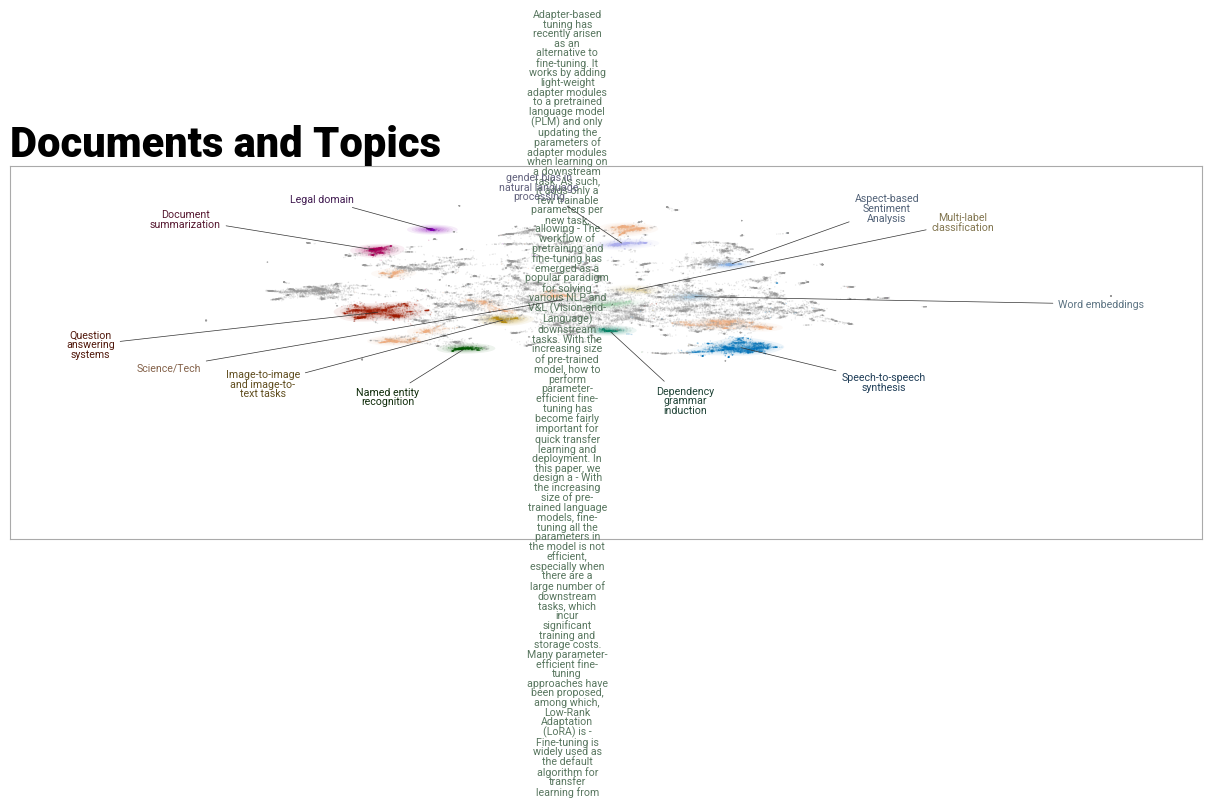

In [ ]:
import matplotlib.pyplot as plt
# Visualizamos los topicos y los clusteres de documentos
fig = topic_model.visualize_document_datamap(
    titles,
    topics=list(range(20)),
    reduced_embeddings=reduced_embeddings,
    width=1200
)
plt.savefig("datamapplot.png", dpi=300)